# Identification of factors

In this notebook, we use some supervised information and enrichment tools on an already trained DRVI model on the immune dataset to identify biological processes captured by latent factors. We combine multiple complementary strategies:

1. **Cell type annotation** — match factors to known cell types. For that you can use:
    * Existing labels
    * Pre-trained classifiers (e.g. CellTypist)
3. **Annotation of Biological Processes** using
    * **Gene set enrichment analysis (GSEA)** — identify enriched pathways from ranked gene lists (BlitzGSEA)
    * **Over-representation analysis (ORA)** — test for enriched gene sets using ordered queries (g:Profiler)
    * **Regulator activity inference** — infer transcription factor or pathway activity using a statistical framework (decoupler) integrated with prior knowledge 

**We always advise examination by a biologist and validation against published literature for any identified processes.**

## Intro

This notebook assumes that you have already trained a DRVI model and computed the interpretability scores (via `model.calculate_interpretability_scores` in the general pipeline).

Please refer to the [General training and interpretability pipeline](./general_pipeline.html) tutorial.

While we use the immune dataset as a running example, all code is dataset-agnostic. Configuration variables at the top of each section indicate what to change for your own data.

### Adapting this notebook to your own dataset

To reuse this notebook on a different dataset or DRVI model:

- Update the `0. Load a previously trained model` section accorfingly.
  - Update `io_dir` to point to your project directory.
  - Make sure the following files exist under `io_dir` with your data (or change the code):
    - `immune_all.h5ad` (or your equivalent full-gene data) in the parent directory.
    - `adata_preprocesses.h5ad` (preprocessed AnnData with HVGs and UMAP)
    - `drvi_model/` (trained DRVI model directory)
    - `embed.h5ad`

### Config Overview
- The notebook contains 5 independent ways to annotate processes. Each having its own config. Some important configs are:
  - **Section 1.1** For identification based on user annotations you have to set `annot_col` to the corresponding column in `adata.obs`.
  - **Section 1.2** For identification based on a pre-trained model. If you use CellTypist you have to choose a model via `ct_model` that matches your tissue / species (e.g. `"Immune_All_Low.pkl"` for PBMC, `"Developing_Mouse_Brain.pkl"` for mouse brain)
  - **Section 2.1** For BlitzGSEA, set:
    - `gsea_db` (e.g `"GO_Biological_Process_2023"`)
    - `fdr_threshold` to keep significant results.
  - **Section 2.2** For g:Profiler, set:
    - `organism` (e.g. `"hsapiens"`, `"mmusculus"`).
    - `gp_source` to the GO / pathway collections you care about (e.g. `["GO:BP"]`, `["REAC"]`).
    - `pval_threshold` to keep significant results.
  - **Section 2.3** For decoupler, set:
    - `dc_geneset` (e.g. `"collectri"`, `"dorothea"`, `"progeny"` or another resource name).
    - `dc_organism` to match your species (e.g. `"human"`, `"mouse"`).
    - `fdr_threshold` to keep significant results.


## Requirements

This notebook requires the following python packages:
```
celltypist
blitzgsea
gprofiler-official
decoupler
```

## Contact

For questions and help requests, you can reach out in the [scverse discourse](https://discourse.scverse.org/).

If you found a bug, please use the [issue tracker](https://github.com/theislab/drvi/issues).

## Install

If you try DRVI on colab, the next cell will install dependencies.

Please remove this part if your environment is already set up.

In [1]:
import sys
import subprocess

branch = "latest"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and branch == "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "drvi[tutorials]"])
elif IN_COLAB and branch != "stable":
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "git+https://github.com/theislab/drvi.git#egg=drvi[tutorials]"])

if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "celltypist", "blitzgsea", "gprofiler-official", "decoupler"])

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import drvi
from pathlib import Path
from drvi.model import DRVI
from drvi.utils.misc import hvg_batch

In [4]:
print("Last run with scvi-tools version:", scvi.__version__)
print("Last run with DRVI version:", drvi.__version__)

Last run with scvi-tools version: 1.4.1
Last run with DRVI version: 0.2.4


In [5]:
# Plot defaults
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (3, 3)

## 0. Load a previously trained model

### Config

In [6]:
# Set input output directory
# We use tmp_io/ directory in the same place as this notebook. Update accordingly.
io_dir = Path("./tmp_io/drvi_immune_128").resolve()
print(f"Using directory: {io_dir}")

Using directory: /lustre/groups/ml01/code/amirali.moinfar/projects/drvi_tutorials/tmp_io/drvi_immune_128


### Load Data

In [7]:
raw_data_path = io_dir.parent / "immune_all.h5ad"
adata_full = sc.read_h5ad(raw_data_path)
adata_full

AnnData object with n_obs × n_vars = 33506 × 12303
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    layers: 'counts'

In [8]:
# The adata which DRVI model is trained on (HVG selected)
adata = sc.read_h5ad(io_dir / "adata_preprocesses.h5ad")
adata

AnnData object with n_obs × n_vars = 32484 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue'
    uns: 'batch_colors', 'final_annotation_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### Load DRVI outputs

In [9]:
model_path = io_dir / "drvi_model"
embed_path = io_dir / "embed.h5ad"


model = DRVI.load(model_path, adata)
embed = sc.read_h5ad(embed_path)

INFO     File                                                                                                      
         /lustre/groups/ml01/code/amirali.moinfar/projects/drvi_tutorials/tmp_io/drvi_immune_128/drvi_model/model.p
         t already downloaded                                                                                      
INFO     DRVI: The model is trained with DRVI version 0.2.4.                                                       
INFO     DRVI: Updaging data setup config ...                                                                      
INFO     DRVI: Done updating data source registry. Loading in DRVI version 0.2.4.                                  
INFO     DRVI: Loading model from DRVI version 0.2.4.                                                              
INFO     DRVI: Done updating model args. Loading in 0.2.4.                                                         
INFO     DRVI: The model has been initialized                           

## 1. Identifying Cell-Type Specific Processes

Some latent factors capture cell-type identity. We can identify these using:
- **Known annotations**: This way we measure alignment between factors and annotated cell types via a similarity measurement like Scaled Mutual Information (SMI). We note that DRVI dimensions may be more fine grained than these annotations, resemble a process covering multiple cell types, or showing general shared processes. However, this approach allows identification of large proportion of processes. For this we need some supervised info such as:
  - **User annotations:** Where user has annotated its data.
  - **Annotation tools**: User can also use pre-trained models such as CellTypist or Foundational Models to classify cells.
- **Enrichment**: Using GSEA/ORA methods with Cell Type databases. This is not described in this tutorial in detail. but same models in **Biological Process Identification** section can be used.

### 1.1 Identification based on user annotations

If your dataset has existing cell type annotations, Scaled Mutual Information (SMI) measures how well each latent factor aligns with each annotated category. SMI is normalized to [0, 1], where 1 indicates perfect correspondence between a factor and a cell type.

**Skip this section if your dataset does not have cell type annotations.**

####  Imports

In [10]:
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

#### Config

In this dataset we have annotations stored in `adata.obs["final_annotation"]`.


In [11]:
# Column in adata.obs containing cell type labels. Set to None if not available.
annot_col = "final_annotation" 

# Minimum SMI score between factor and cell-type probability profiles to consider a factor as associated with a cell type. Adjust as needed.
smi_threshold = 0.7

#### Visualize with a Heatmap

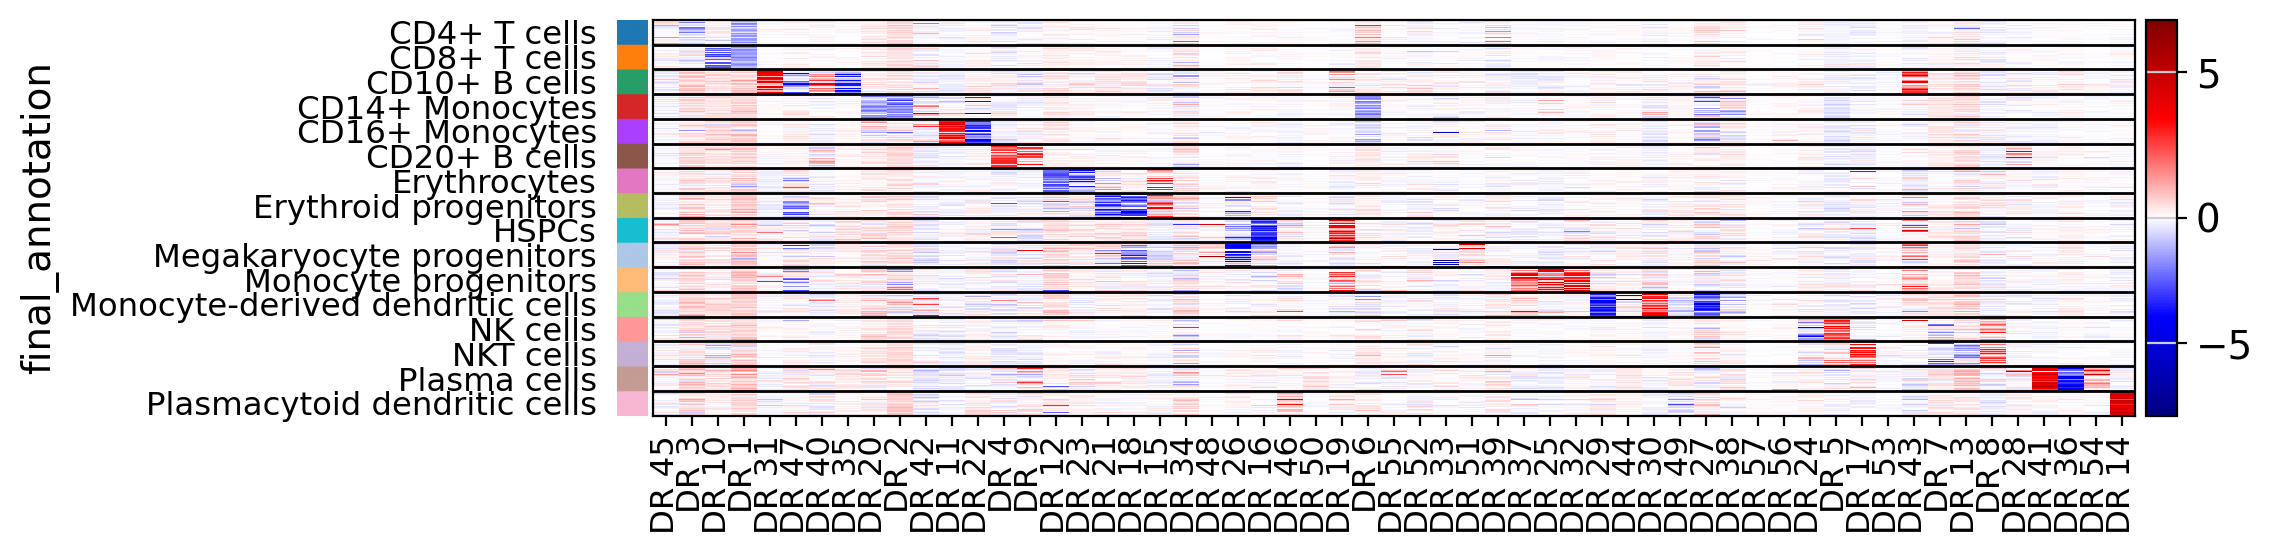

In [12]:
drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, 
    annot_col, 
    title_col="title", 
    sort_by_categorical=True,
)

We observe very good one-to-one relationship between some factors and cell types. Let's identify them

#### Prepare data

We prepare a matrix where columns are positive and negative nonvanished latent factors and rows are cells

In [13]:
embed_pos = embed[:, ~embed.var['vanished_positive_direction']].copy()
embed_neg = embed[:, ~embed.var['vanished_negative_direction']].copy()
embed_pos.var.index = embed_pos.var['title'] + '+'
embed_neg.var.index = embed_neg.var['title'] + '-'
embed_pos.X = embed_pos.X.clip(min=0)
embed_neg.X = -embed_neg.X.clip(max=0)
embed_directional_df = pd.concat([embed_pos.to_df(), embed_neg.to_df()], axis=1).loc[embed.obs.index]
embed_directional_df[:3]

title,DR 32+,DR 33+,DR 18+,DR 9+,DR 42+,DR 20+,DR 53+,DR 13+,DR 19+,DR 25+,...,DR 11-,DR 49-,DR 22-,DR 43-,DR 3-,DR 37-,DR 28-,DR 23-,DR 45-,DR 44-
index,,,,,,,,,,,,,,,,,,,,,
CTCCTAGGTCTCACCT-1-Oetjen_U,0.210336,0.000000,0.152848,0.000000,0.074445,0.406338,0.102672,0.423813,0.100138,0.020391,...,0.284391,-0.0,-0.000000,0.036090,0.177264,0.037022,0.019228,-0.000000,-0.000000,-0.0
ACACAGTAGGTGCATG-1-10X,0.000000,0.000000,0.089803,0.051229,0.604815,0.000000,0.268985,0.000000,0.054692,0.202580,...,-0.000000,-0.0,0.058529,0.279276,0.474983,-0.000000,0.472323,0.064648,-0.000000,-0.0
CGACTTCGTAGCGTCC-1-Oetjen_A,3.845079,0.113546,0.077944,0.000000,0.000000,0.000000,0.000000,0.671429,1.998806,0.769830,...,0.090059,-0.0,0.335960,-0.000000,-0.000000,-0.000000,0.238744,-0.000000,0.445071,-0.0


#### Calculation of Scaled Mutual Information

We use `DiscreteDisentanglementBenchmark` class that we use for evaluation of models. This class calculated pairwise similarity function between latent factors and supervised targets.

In [14]:
# Compute SMI between each factor-direction (+/-) and each annotated cell type.
benchmark = DiscreteDisentanglementBenchmark(
    embed_directional_df.values,
    dim_titles=embed_directional_df.columns,
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=[],
)
benchmark.evaluate()
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity.index.name = "title"

In [15]:
print(f"SMI matrix shape: {smi_similarity.shape} (factor-directions x cell types)")
smi_similarity[:3]

SMI matrix shape: (113, 16) (factor-directions x cell types)


,CD4+ T cells,CD8+ T cells,CD10+ B cells,CD14+ Monocytes,CD16+ Monocytes,CD20+ B cells,Erythrocytes,Erythroid progenitors,HSPCs,Megakaryocyte progenitors,Monocyte progenitors,Monocyte-derived dendritic cells,NK cells,NKT cells,Plasma cells,Plasmacytoid dendritic cells
title,,,,,,,,,,,,,,,,
DR 32+,0.010493,0.004168,0.002685,0.002501,0.003521,0.005020,0.003258,0.001405,0.104420,0.015237,0.585979,0.003438,0.004249,0.004666,0.005150,0.002802
DR 33+,0.024124,0.028036,0.046029,0.000599,0.001436,0.007010,0.000602,0.008520,0.028649,0.007115,0.001189,0.007875,0.047094,0.017784,0.011491,0.001662
DR 18+,0.007033,0.002999,0.189484,0.001562,0.001576,0.015449,0.026948,0.028221,0.148079,0.015255,0.074891,0.079624,0.011926,0.002005,0.033200,0.003687


In [16]:
# Reshape the SMI matrix from wide to long format, then keep only pairs above the threshold.
smi_top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars="title", value_vars=smi_similarity.columns)
    .query("value >= @smi_threshold")
    .reset_index(drop=True)
    .sort_values("value", ascending=False)
)
print(f"Factor–cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
smi_top_matches

Factor–cell type pairs with SMI >= 0.7: 13


,title,variable,value
12,DR 14+,Plasmacytoid dendritic cells,0.930836
10,DR 41+,Plasma cells,0.911333
4,DR 11+,CD16+ Monocytes,0.907092
9,DR 29-,Monocyte-derived dendritic cells,0.894936
11,DR 36-,Plasma cells,0.882409
5,DR 4+,CD20+ B cells,0.856307
3,DR 2-,CD14+ Monocytes,0.815685
0,DR 31+,CD10+ B cells,0.780098
8,DR 16-,HSPCs,0.743234
2,DR 6-,CD14+ Monocytes,0.729184


#### Helper function for relationship Visualization

In [17]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value", figsize=(14, 10)):
    """Visualizes factor–cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = 3
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=figsize)
    titles = set(df[title_col])
    weights = [d[val_col] for u, v, d in G.edges(data=True)]
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[w * 4 for w in weights],
        edge_color=weights, edge_cmap=plt.cm.Oranges, alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

#### Plot Packed Visualization

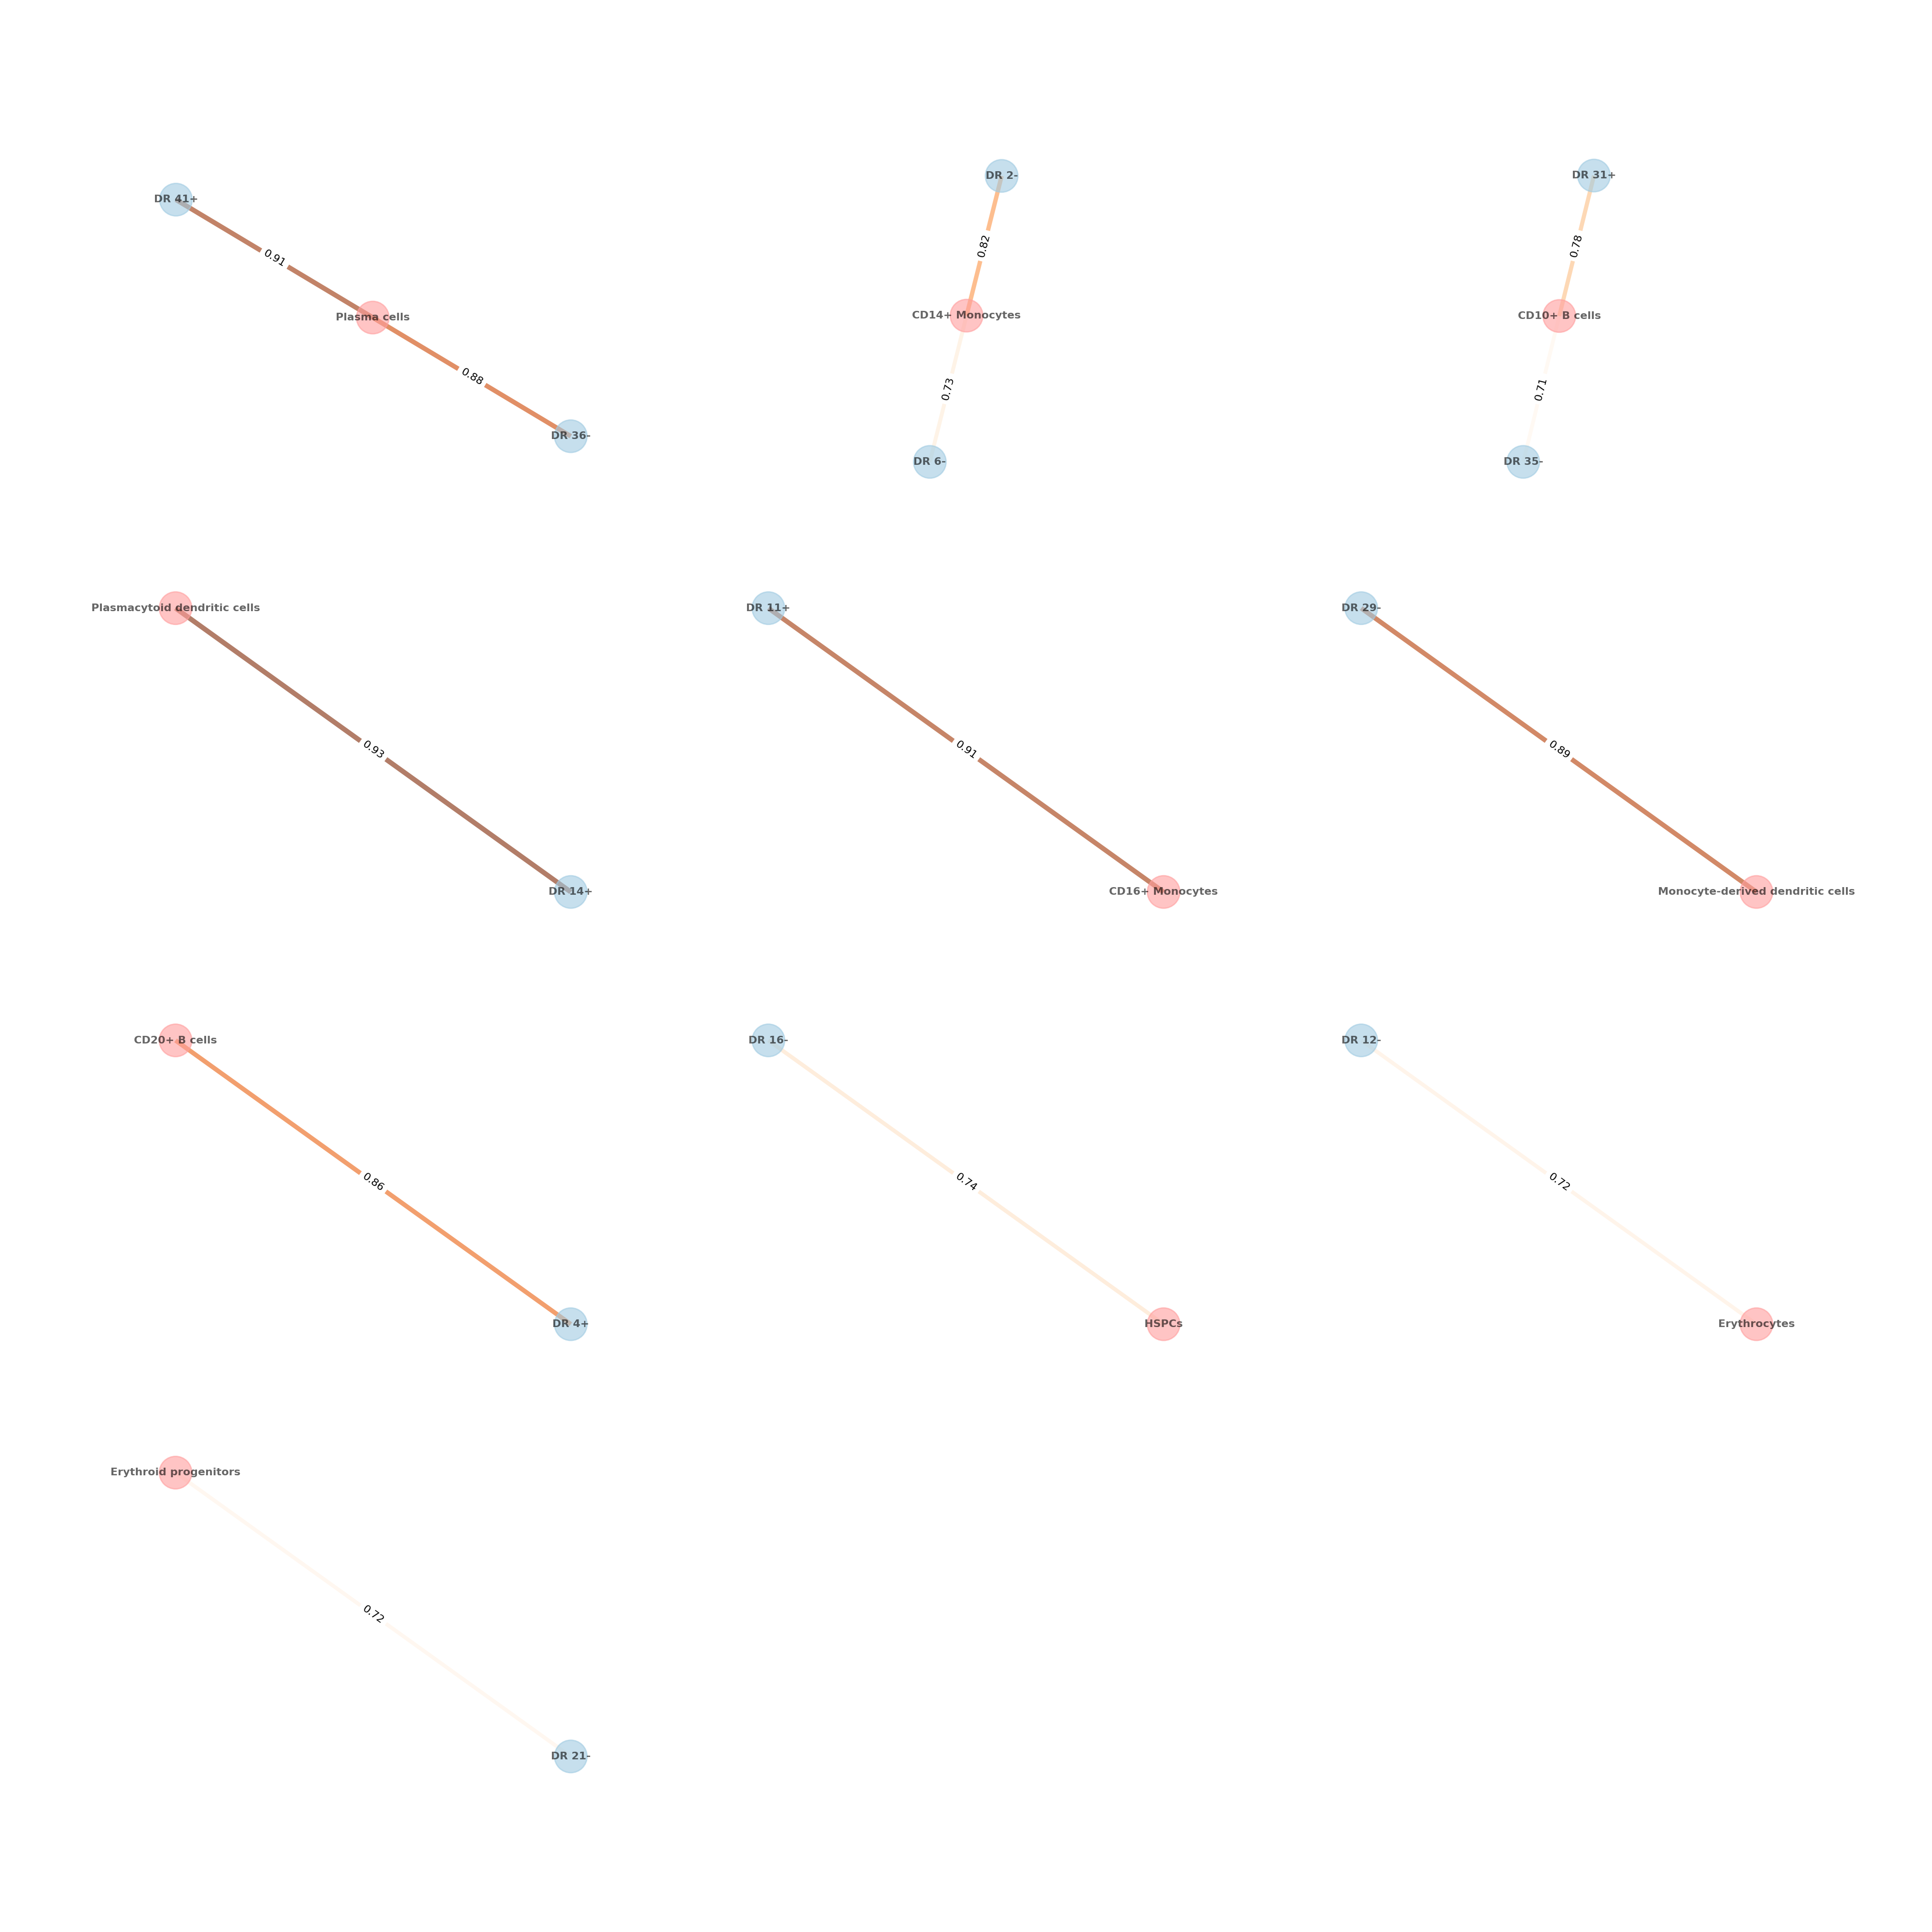

In [18]:
plot_packed_network(smi_top_matches, figsize=(20, 20))

#### Store summary in var

In [19]:
first_match = smi_top_matches.drop_duplicates(subset=['title'])
first_match['direction'] = first_match['title'].str[-1:]
first_match['title'] = first_match['title'].str[:-1]
first_match_pos = first_match.query("direction == '+'")
first_match_neg = first_match.query("direction == '-'")
embed.var.set_index("title", drop=False, inplace=True)
embed.var[f'positive_direction_match_with_{annot_col}'] = None
embed.var[f'negative_direction_match_with_{annot_col}'] = None
embed.var[f'positive_direction_match_with_{annot_col}'][first_match_pos['title']] = first_match_pos['variable']
embed.var[f'negative_direction_match_with_{annot_col}'][first_match_neg['title']] = first_match_neg['variable']
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

(
    embed.var[f'positive_direction_match_with_{annot_col}'].unique(),
    embed.var[f'negative_direction_match_with_{annot_col}'].unique(),
)

(array([None, 'CD20+ B cells', 'CD10+ B cells',
        'Plasmacytoid dendritic cells', 'Plasma cells', 'CD16+ Monocytes'],
       dtype=object),
 array([None, 'CD14+ Monocytes', 'Erythroid progenitors', 'Erythrocytes',
        'CD10+ B cells', 'Monocyte-derived dendritic cells',
        'Plasma cells', 'HSPCs'], dtype=object))

#### Store results in uns

In [20]:
embed.uns[f'best_smi_matching_{annot_col}_results'] = smi_top_matches

### 1.2 Identification based on pre-trained model

Here, we use [CellTypist](https://www.celltypist.org/) as a pre-trained logistic regression model trained on large-scale annotated atlases to classify individual cells. We calculate the Similarity Mutual Information (SMI) between the CellTypist probability matrix (cells × cell types) and the DRVI factor activity matrix (cells × factors) to identify which factors correspond to which cell types.

**Note 1: Users can skip this if they already have good annotations.**

**Note 2: Only the annotation part is different from the previous section and everything is duplicate from `prepare data` section.**

#### Imports

In [21]:
import celltypist
import networkx as nx
from drvi.utils.metrics import DiscreteDisentanglementBenchmark

#### Config

In [22]:
# Minimum SMI score between factor and cell-type probability profiles to consider a factor as associated with a cell type. Adjust as needed.
smi_threshold = 0.7

# We use "celltypist_majority" from cell typisy outputs
annot_col = "celltypist_majority"

In [23]:
# CellTypist Model

# Run celltypist.models.models_description() to see all available models. Choose one matching your tissue. 
ct_model = "Immune_All_Low.pkl"  # e.g., "Developing_Mouse_Brain.pkl" for mouse brain
celltypist.models.download_models(force_update=False, model=ct_model)

ct_model = celltypist.models.Model.load(model=ct_model)
# Run print(ct_model.cell_types) to see available cell types

📂 Storing models in /home/icb/amirali.moinfar/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)


#### CellTypist Annotation

Each cell receives a predicted label via logistic regression based on its transcriptomic profile. Setting majority_voting=True refines these labels by assigning the most frequent label within a cell's local neighborhood (kNN), reducing technical noise. The resulting per-cell labels are stored in adata.obs.

In [24]:
# We use full anndata (all genes) see Ce;;Typist docs for more info
adata_full.X = adata_full.layers['counts'].copy()
sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

predictions = celltypist.annotate(adata_full, model=ct_model, majority_voting=True)

🔬 Input data has 33506 cells and 12303 genes
🔗 Matching reference genes in the model
🧬 4296 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [25]:
embed.obs["celltypist_labels"] = predictions.predicted_labels["predicted_labels"].loc[embed.obs.index]
embed.obs["celltypist_majority"] = predictions.predicted_labels["majority_voting"].loc[embed.obs.index]
embed.obsm["celltypist_probs"] = predictions.probability_matrix[embed.obs["celltypist_majority"].cat.categories].loc[embed.obs.index]

#### Visualize with a Heatmap

... storing 'positive_direction_match_with_final_annotation' as categorical
... storing 'negative_direction_match_with_final_annotation' as categorical


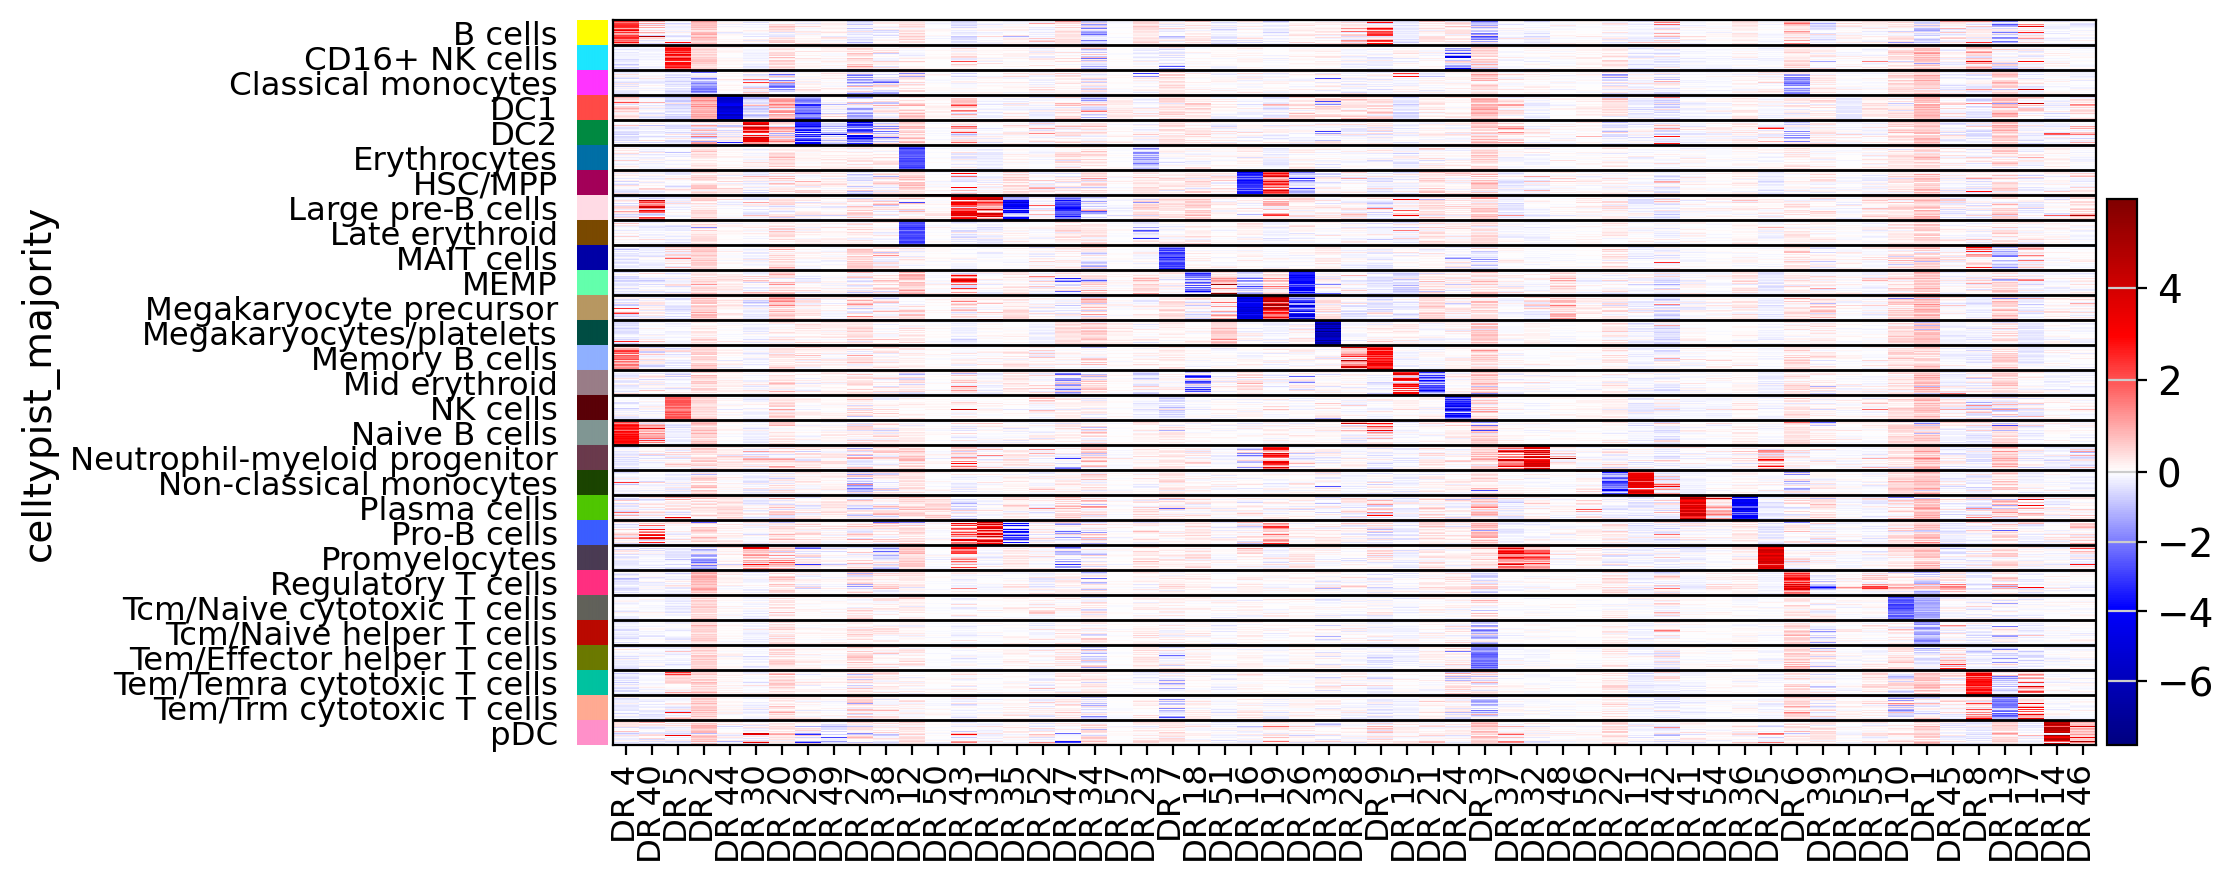

In [26]:
drvi.utils.pl.plot_latent_dims_in_heatmap(
    embed, 
    annot_col, 
    title_col="title", 
    sort_by_categorical=True,
)

We observe very good one-to-one relationship between some factors and cell types. Let's identify them

#### Prepare data

We prepare a matrix where columns are positive and negative nonvanished latent factors and rows are cells

In [27]:
embed_pos = embed[:, ~embed.var['vanished_positive_direction']].copy()
embed_neg = embed[:, ~embed.var['vanished_negative_direction']].copy()
embed_pos.var.index = embed_pos.var['title'] + '+'
embed_neg.var.index = embed_neg.var['title'] + '-'
embed_pos.X = embed_pos.X.clip(min=0)
embed_neg.X = -embed_neg.X.clip(max=0)
embed_directional_df = pd.concat([embed_pos.to_df(), embed_neg.to_df()], axis=1).loc[embed.obs.index]
embed_directional_df[:3]

title,DR 32+,DR 33+,DR 18+,DR 9+,DR 42+,DR 20+,DR 53+,DR 13+,DR 19+,DR 25+,...,DR 11-,DR 49-,DR 22-,DR 43-,DR 3-,DR 37-,DR 28-,DR 23-,DR 45-,DR 44-
index,,,,,,,,,,,,,,,,,,,,,
CTCCTAGGTCTCACCT-1-Oetjen_U,0.210336,0.000000,0.152848,0.000000,0.074445,0.406338,0.102672,0.423813,0.100138,0.020391,...,0.284391,-0.0,-0.000000,0.036090,0.177264,0.037022,0.019228,-0.000000,-0.000000,-0.0
ACACAGTAGGTGCATG-1-10X,0.000000,0.000000,0.089803,0.051229,0.604815,0.000000,0.268985,0.000000,0.054692,0.202580,...,-0.000000,-0.0,0.058529,0.279276,0.474983,-0.000000,0.472323,0.064648,-0.000000,-0.0
CGACTTCGTAGCGTCC-1-Oetjen_A,3.845079,0.113546,0.077944,0.000000,0.000000,0.000000,0.000000,0.671429,1.998806,0.769830,...,0.090059,-0.0,0.335960,-0.000000,-0.000000,-0.000000,0.238744,-0.000000,0.445071,-0.0


#### Calculation of Scaled Mutual Information

We use `DiscreteDisentanglementBenchmark` class that we use for evaluation of models. This class calculated pairwise similarity function between latent factors and supervised targets.

In [28]:
# Compute SMI between each factor-direction (+/-) and each cell type probability.
benchmark = DiscreteDisentanglementBenchmark(
    embed_directional_df.values,
    dim_titles=embed_directional_df.columns,
    discrete_target=embed.obs[annot_col],
    metrics=["SMI-disc"],
    aggregation_methods=[],
)
benchmark.evaluate()
smi_similarity = benchmark.get_results_details()["SMI-disc"]
smi_similarity.index.name = "title"

In [29]:
print(f"SMI matrix shape: {smi_similarity.shape} (factor-directions x cell types)")
smi_similarity[:3]

SMI matrix shape: (113, 29) (factor-directions x cell types)


,B cells,CD16+ NK cells,Classical monocytes,DC1,DC2,Erythrocytes,HSC/MPP,Large pre-B cells,Late erythroid,MAIT cells,...,Plasma cells,Pro-B cells,Promyelocytes,Regulatory T cells,Tcm/Naive cytotoxic T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,pDC
title,,,,,,,,,,,,,,,,,,,,,
DR 32+,0.002191,0.004125,0.005175,0.002105,0.002364,0.002819,0.095555,0.002344,0.003096,0.003795,...,0.005150,0.007065,0.657446,0.002828,0.003748,0.009642,0.003718,0.003673,0.003916,0.002217
DR 33+,0.018338,0.046772,0.000617,0.108819,0.001484,0.011760,0.014261,0.068921,0.006430,0.053423,...,0.013743,0.029083,0.001972,0.001450,0.024826,0.029380,0.003147,0.005590,0.005285,0.004689
DR 18+,0.050323,0.012902,0.001514,0.122026,0.067661,0.004580,0.162137,0.306243,0.028364,0.006225,...,0.035638,0.118337,0.103980,0.009751,0.009790,0.003717,0.023244,0.012259,0.013682,0.006561


In [30]:
# Reshape the SMI matrix from wide to long format, then keep only pairs above the threshold.
smi_top_matches = (
    smi_similarity.reset_index()
    .melt(id_vars="title", value_vars=smi_similarity.columns)
    .query("value >= @smi_threshold")
    .reset_index(drop=True)
    .sort_values("value", ascending=False)
)
print(f"Factor–cell type pairs with SMI >= {smi_threshold}: {len(smi_top_matches)}")
smi_top_matches

Factor–cell type pairs with SMI >= 0.7: 23


,title,variable,value
15,DR 41+,Plasma cells,0.961395
16,DR 36-,Plasma cells,0.934470
9,DR 33-,Megakaryocytes/platelets,0.929647
2,DR 44-,DC1,0.927105
14,DR 11+,Non-classical monocytes,0.913611
11,DR 21-,Mid erythroid,0.888247
10,DR 9+,Memory B cells,0.861224
0,DR 5+,CD16+ NK cells,0.858324
7,DR 26-,MEMP,0.855364
12,DR 4+,Naive B cells,0.852754


#### Helper function for relationship Visualization

In [31]:
def plot_packed_network(df, title_col="title", var_col="variable", val_col="value", figsize=(14, 10)):
    """Visualizes factor–cell type associations as a network with edge weights."""
    G = nx.from_pandas_edgelist(df, title_col, var_col, edge_attr=val_col)

    pos = {}
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    cols = 3
    for i, nodes in enumerate(components):
        sub_pos = nx.spring_layout(G.subgraph(nodes), weight=val_col, k=0.5, seed=42)
        r, c = divmod(i, cols)
        for n, (x, y) in sub_pos.items():
            pos[n] = (x + c * 3, y - r * 3)

    plt.figure(figsize=figsize)
    titles = set(df[title_col])
    weights = [d[val_col] for u, v, d in G.edges(data=True)]
    nx.draw(
        G, pos,
        with_labels=True, font_size=8, font_weight="bold", node_size=600,
        node_color=["#A0CBE2" if n in titles else "#FF9E9E" for n in G.nodes()],
        width=[w * 4 for w in weights],
        edge_color=weights, edge_cmap=plt.cm.Oranges, alpha=0.6,
    )
    edge_labels = {(u, v): f"{d[val_col]:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.axis("off")
    plt.show()

#### Plot Packed Visualization

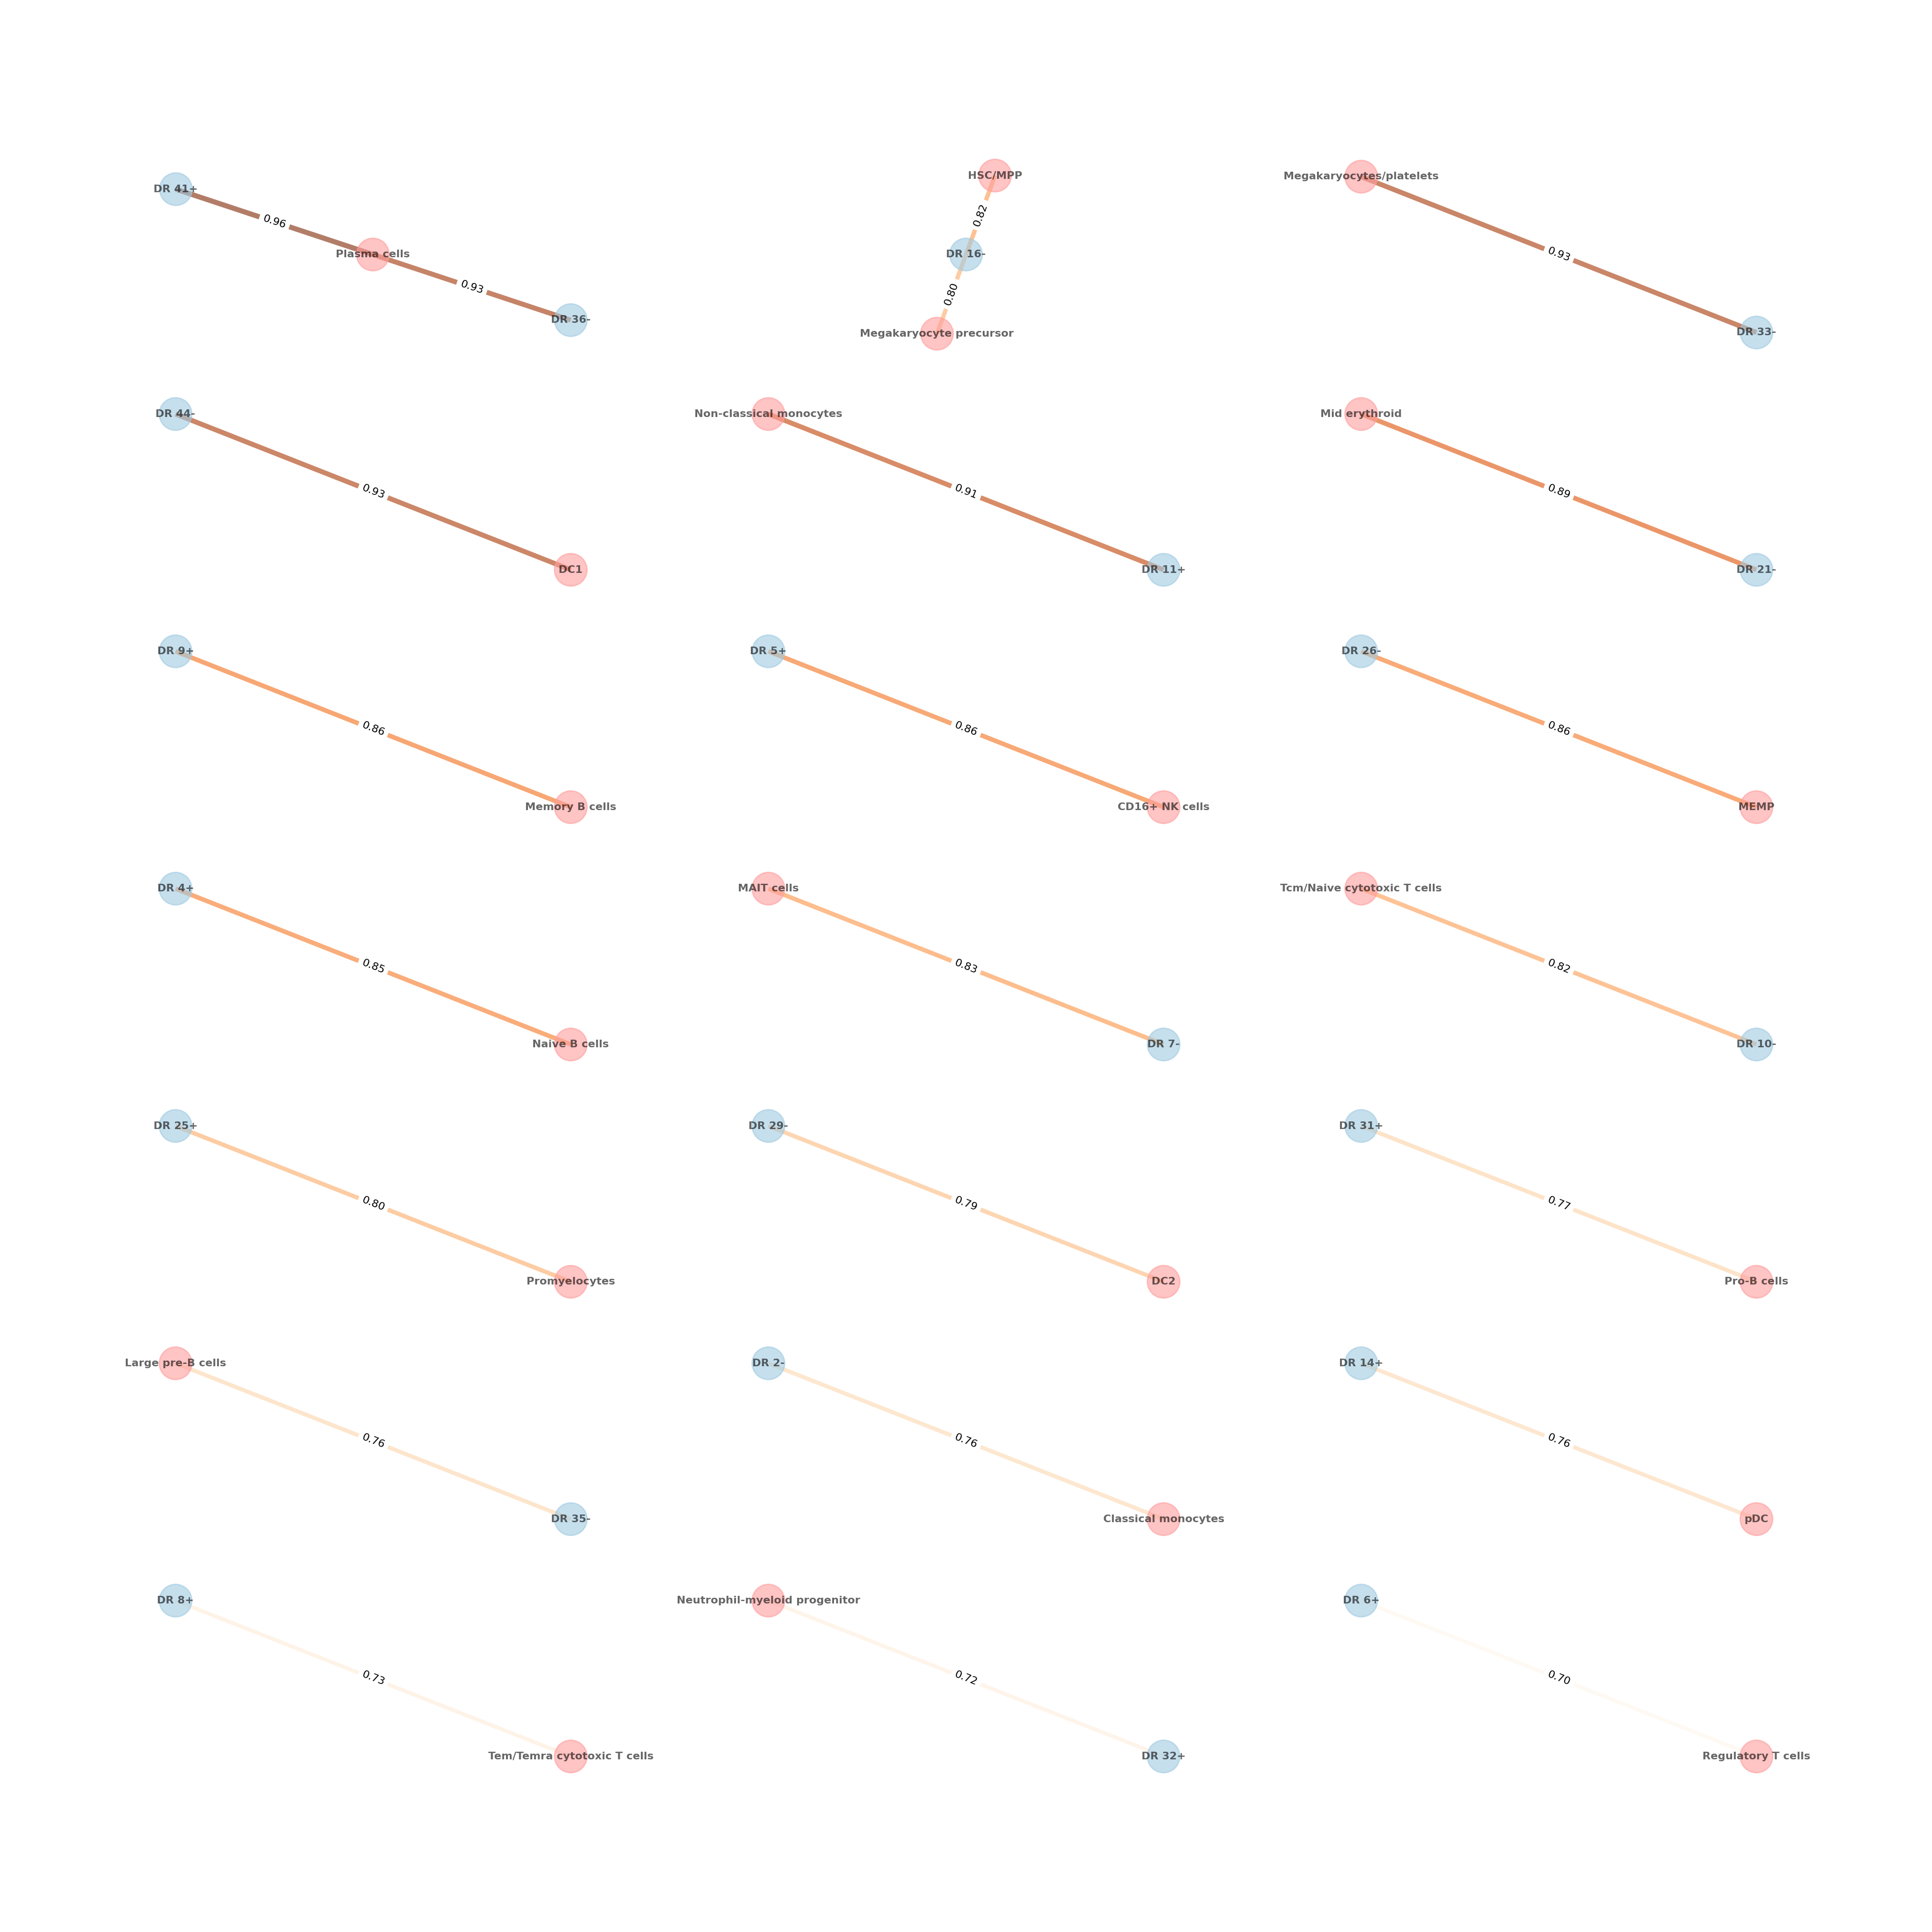

In [32]:
plot_packed_network(smi_top_matches, figsize=(20, 20))

#### Store summary in var

In [33]:
first_match = smi_top_matches.drop_duplicates(subset=['title'])
first_match['direction'] = first_match['title'].str[-1:]
first_match['title'] = first_match['title'].str[:-1]
first_match_pos = first_match.query("direction == '+'")
first_match_neg = first_match.query("direction == '-'")
embed.var.set_index("title", drop=False, inplace=True)
embed.var[f'positive_direction_match_with_{annot_col}'] = None
embed.var[f'negative_direction_match_with_{annot_col}'] = None
embed.var[f'positive_direction_match_with_{annot_col}'][first_match_pos['title']] = first_match_pos['variable']
embed.var[f'negative_direction_match_with_{annot_col}'][first_match_neg['title']] = first_match_neg['variable']
embed.var.index = embed.var["original_dim_id"].astype(int).astype(str)
embed.var.index.name = None

(
    embed.var[f'positive_direction_match_with_{annot_col}'].unique(),
    embed.var[f'negative_direction_match_with_{annot_col}'].unique(),
)

(array(['Neutrophil-myeloid progenitor', None, 'Memory B cells',
        'Promyelocytes', 'Naive B cells', 'CD16+ NK cells',
        'Regulatory T cells', 'Tem/Temra cytotoxic T cells', 'Pro-B cells',
        'pDC', 'Plasma cells', 'Non-classical monocytes'], dtype=object),
 array([None, 'Megakaryocytes/platelets', 'Tcm/Naive cytotoxic T cells',
        'Mid erythroid', 'MEMP', 'MAIT cells', 'Large pre-B cells', 'DC2',
        'Plasma cells', 'Classical monocytes', 'HSC/MPP', 'DC1'],
       dtype=object))

#### Store results in uns

In [34]:
embed.uns[f'best_smi_matching_{annot_col}_results'] = smi_top_matches

## 2. Biological process identification

Factors that do not map to a single cell type often capture biological processes (e.g., interferon response, cell cycle, stress). We use three complementary enrichment approaches, each with different strengths:

| Tool | Method | Input | Strengths |
|------|--------|-------|-----------|
| **BlitzGSEA** | Pre-ranked GSEA | Full ranked gene list | Fast; uses entire ranking; uses an analytical null distribution |
| **g:Profiler** | Over-representation (ORA) | Ordered gene query | Robust multiple-testing (g:SCS); well-suited for biological pathways and GO terms |
| **decoupler** | Activity Inference (ULM/MLM) | Gene score matrix + Prior Knowledge | Regression-based; identifies specific regulatory drivers (e.g., TFs) using curated networks |

Each tool operates on the gene-level interpretability scores produced by DRVI's built-in scoring API (`model.get_interpretability_scores`). DRVI provides two complementary scoring approaches that can be selected via config variables later:

- **OOD (Out-of-Distribution)**: Uses decoder reconstructions to calculate per-gene effect scores. This is our suggested method to consider for finding cell-types and most specific genes of a program. This is stored with `"OOD_combined"` key.
- **IND (withIN-Distribution)**: Iterates over all cells to compute weighted mean effects. Captures broader mechanistic effects including shared genes. This is stored with `"IND_linear_weighted_mean"` key.

All tools in this notebook are **guiding tools**: they summarize large gene-level patterns into interpretable scores, but they do **not** provide definitive labels. Their outputs should always be interpreted in context, compared across methods, and validated against known biology and the original data.

### 2.1 BlitzGSEA

[BlitzGSEA](https://github.com/MaayanLab/blitzgsea) performs pre-ranked Gene Set Enrichment Analysis using an analytical approximation of the null distribution rather than permutations, enabling high-performance enrichment testing across many factors.

- **Input**: Full ranked gene list (genes sorted by their DRVI effect scores, capturing the magnitude and direction of expression change)
- **Output**: Normalized Enrichment Score (NES) and FDR-adjusted p-values per gene set
- **Database**: Compatible with any standard .gmt file or Enrichr library (e.g., MSigDB, Reactome)

In [35]:
import blitzgsea as blitz

#### Config

In [36]:
# Enrichr library to use. See Appendix for available databases.
# Common choices: "MSigDB_Hallmark_2020", "GO_Biological_Process_2023",
#                 "Reactome_2022", "KEGG_2021_Human"

gsea_db = "GO_Biological_Process_2023"

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)

score_key = "OOD_combined"

# Significance threshold
fdr_threshold = 0.05

print(f"GSEA DB: {gsea_db}")
print(f"Score key: {score_key}")
print(f"FDR threshold: {fdr_threshold}")

GSEA DB: GO_Biological_Process_2023
Score key: OOD_combined
FDR threshold: 0.05


In [37]:
signature_lib = blitz.enrichr.get_library(gsea_db)
print(f"Loaded {gsea_db}: {len(signature_lib)} gene sets")

Loaded GO_Biological_Process_2023: 5407 gene sets


#### Prepare data

In [38]:
# once again: you can set score_key in main config of the notebook
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)
scores_df

title,DR 1+,DR 1-,DR 2+,DR 2-,DR 3+,DR 3-,DR 4+,DR 4-,DR 5+,DR 5-,...,DR 53+,DR 53-,DR 54+,DR 54-,DR 55+,DR 55-,DR 56+,DR 56-,DR 57+,DR 57-
index,,,,,,,,,,,,,,,,,,,,,
TCL1A,0.000000e+00,0.003434,4.446418e-12,3.660301e-04,0.000000e+00,6.804818e-04,1.750993,6.523098e-11,0.000476,1.283398e-11,...,9.243852e-05,5.209384e-11,3.023486e-06,1.336275e-09,8.293920e-07,2.711936e-09,0.001902,7.238062e-11,6.523226e-05,1.676755e-10
IGLL5,3.157968e-13,0.000496,0.000000e+00,1.697363e-04,8.084397e-13,2.029641e-04,0.203205,0.000000e+00,0.000016,0.000000e+00,...,2.781705e-04,0.000000e+00,4.828859e-02,0.000000e+00,1.594675e-05,0.000000e+00,0.016821,0.000000e+00,2.513448e-05,0.000000e+00
PTGDS,1.010550e-11,0.001391,2.531427e-11,6.186076e-04,3.693559e-11,8.280926e-03,0.000001,3.327439e-08,0.694148,1.205080e-11,...,7.180473e-05,3.648589e-10,7.078154e-06,1.366010e-10,2.989708e-07,1.803326e-10,0.001692,4.984536e-11,9.004977e-05,5.515580e-10
GZMB,1.134089e-10,0.011291,1.421187e-09,1.063482e-03,1.061229e-09,8.550176e-04,0.000481,9.307921e-10,1.300306,1.842358e-09,...,2.927855e-04,1.167210e-08,4.170948e-05,2.235548e-08,5.254718e-06,8.505266e-09,0.000033,7.081326e-09,8.822727e-08,4.047072e-08
PPBP,6.782052e-10,0.000976,2.212902e-09,5.111832e-04,4.776616e-09,7.869431e-05,0.000025,6.237365e-09,0.000050,4.240266e-09,...,3.795505e-07,1.857370e-08,8.281008e-07,6.667809e-09,8.460714e-08,1.229932e-08,0.000021,5.171993e-09,1.241326e-07,9.176018e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LCNL1,5.848556e-12,0.000248,1.515825e-13,1.056490e-03,2.400056e-13,5.926474e-03,0.000188,2.425319e-12,0.044215,0.000000e+00,...,1.489906e-04,5.052748e-14,2.003104e-07,0.000000e+00,1.685374e-07,2.501110e-12,0.000369,2.779012e-13,2.364960e-05,2.526374e-14
CAMK2N1,1.515825e-13,0.014901,1.746946e-08,7.338801e-07,3.536924e-13,7.195686e-02,0.000099,2.467889e-10,0.000173,5.162229e-09,...,2.551514e-04,6.985425e-12,5.643703e-06,3.463280e-10,1.382063e-07,3.228959e-10,0.000270,2.753748e-12,1.286025e-05,6.745419e-12
SH3TC2,1.347821e-11,0.017847,2.526374e-13,2.980847e-01,6.758051e-11,1.748504e-03,0.001171,1.136868e-13,0.000398,1.025708e-11,...,1.016934e-06,5.684342e-13,1.749210e-07,1.692671e-12,4.484557e-07,4.547474e-13,0.000044,4.547474e-13,1.877135e-07,0.000000e+00


#### Enrichment

In [39]:
blitzgsea_rows = []

for factor_label in scores_df.columns:
    series = scores_df[factor_label]

    # BlitzGSEA expects a DataFrame with columns "i" (gene) and "v" (score)
    signature = series.rename("v").reset_index().rename(columns={"index": "i"})
    signature["v"] = pd.to_numeric(signature["v"], errors="coerce")
    signature = signature.replace([np.inf, -np.inf], np.nan).dropna(subset=["v"])

    try:
        res = blitz.gsea(signature, signature_lib, processes=4)
        sig = res[res["fdr"] < fdr_threshold].sort_values("fdr")
        if len(sig):
            # Keep up to the top 3 most significant terms per factor-direction
            top_sig = sig.head(3)
            for term, row in top_sig.iterrows():
                blitzgsea_rows.append({
                    "factor": factor_label,
                    "term": term,
                    "NES": round(float(row["nes"]), 3),
                    "FDR": float(row["fdr"]),
                })
    except Exception as e:
        print(f"BlitzGSEA failed for {factor_label}: {e}")

In [40]:
blitzgsea_results = pd.DataFrame(blitzgsea_rows)
print(
    f"BlitzGSEA significant directions: {blitzgsea_results['factor'].nunique()} / {scores_df.shape[1]} "
    f"(with up to 3 terms per direction)"
)
blitzgsea_results.sort_values(["factor", "FDR"])

BlitzGSEA significant directions: 4 / 113 (with up to 3 terms per direction)


,factor,term,NES,FDR
1,DR 13+,Regulation Of Interleukin-13 Production (GO:00...,3.816,0.031960
2,DR 13+,Negative Regulation Of Leukocyte Degranulation...,3.812,0.031960
3,DR 13+,Regulation Of Interleukin-5 Production (GO:003...,3.812,0.031960
4,DR 33+,Type II Interferon-Mediated Signaling Pathway ...,5.208,0.000321
5,DR 33+,Cellular Response To Interferon-Beta (GO:0035458),4.790,0.000848
6,DR 33+,Regulation Of Toll-Like Receptor Signaling Pat...,4.786,0.000848
0,DR 4-,Immunoglobulin Mediated Immune Response (GO:00...,-4.312,0.027329
7,DR 51-,Interleukin-27-Mediated Signaling Pathway (GO:...,5.166,0.000209
8,DR 51-,Type II Interferon-Mediated Signaling Pathway ...,5.160,0.000209
9,DR 51-,Protein Localization To Golgi Apparatus (GO:00...,4.713,0.000704


#### Store results

In [41]:
# dtype conversion is to be able to write as h5ad
embed.uns[f'blitzgsea_{gsea_db}_results'] = blitzgsea_results.convert_dtypes(convert_integer=False, convert_floating=False)

### 2.2 g:Profiler

[g:Profiler](https://biit.cs.ut.ee/gprofiler/) performs Over-Representation Analysis (ORA) using a hypergeometric test. It employs a custom multiple-testing correction (g:SCS), which is specifically optimized to handle the hierarchical and overlapping structure of Gene Ontology terms.

In **ordered query** mode, g:Profiler processes genes sorted by their DRVI effect scores and iteratively tests enrichment at increasing increments. This approach automatically identifies the optimal gene set size for enrichment, making it more sensitive than using a fixed "top-N" cutoff for continuous latent factor scores.

How it works:
- **Input**: Ordered gene list (genes sorted by absolute or directional traverse effect scores)
- **Output**: Enriched terms with p-values corrected via g:SCS
- **Database**: Comprehensive support for GO (BP, MF, CC), Reactome, KEGG, WikiPathways, and regulatory motifs

Many functional annotation collections (for example Gene Ontology, pathway databases, or phenotype ontologies) are hierarchical and redundant. Broad "umbrella" terms tend to be enriched across multiple latent factors, while more specific child terms capture finer-grained biology. Because of this structure, there is rarely a single automatically chosen term that is clearly "the" correct label for a factor.

In this tutorial, we therefore treat g:Profiler as a tool to obtain **shortlists of enriched terms per factor-direction**, not as an automatic source of single-factor labels.

**Key configuration** (set in the next cell): `organism` (e.g. `"hsapiens"`, `"mmusculus"`) and `gp_source` (e.g. `["GO:BP"]`, `["REAC"]`).

In [42]:
from gprofiler import GProfiler

#### Config

In [43]:
# Organism string. Common values: "hsapiens", "mmusculus", "drerio"
organism = "hsapiens"

# Source database(s).
# Common choices: ["GO:BP"], ["GO:MF"], ["GO:CC"], ["REAC"], ["KEGG"], ["HP"]
gp_source = ["GO:BP"]

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)

score_key = "OOD_combined"
# Gene-set filtering criteria
drvi_score_cutoff = 0.5  # Practically 0.1 for OOD and 0.5 for IND should be good values
drvi_n_top_genes = 100  # maximum top genes per program to consider

# Significance threshold
pval_threshold = 0.05

print(f"Organism: {organism}")
print(f"GP Sources: {gp_source}")
print(f"Score key: {score_key}")
print(f"Cutoff - min score : {drvi_score_cutoff}")
print(f"Cutoff - maximum # of top genes: {drvi_n_top_genes}")
print(f"P-val culoff threshold: {pval_threshold}")

Organism: hsapiens
GP Sources: ['GO:BP']
Score key: OOD_combined
Cutoff - min score : 0.5
Cutoff - maximum # of top genes: 100
P-val culoff threshold: 0.05


#### Prepare data

In [44]:
# once again: you can set score_key in main config of the notebook
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)
scores_df

title,DR 1+,DR 1-,DR 2+,DR 2-,DR 3+,DR 3-,DR 4+,DR 4-,DR 5+,DR 5-,...,DR 53+,DR 53-,DR 54+,DR 54-,DR 55+,DR 55-,DR 56+,DR 56-,DR 57+,DR 57-
index,,,,,,,,,,,,,,,,,,,,,
TCL1A,0.000000e+00,0.003434,4.446418e-12,3.660301e-04,0.000000e+00,6.804818e-04,1.750993,6.523098e-11,0.000476,1.283398e-11,...,9.243852e-05,5.209384e-11,3.023486e-06,1.336275e-09,8.293920e-07,2.711936e-09,0.001902,7.238062e-11,6.523226e-05,1.676755e-10
IGLL5,3.157968e-13,0.000496,0.000000e+00,1.697363e-04,8.084397e-13,2.029641e-04,0.203205,0.000000e+00,0.000016,0.000000e+00,...,2.781705e-04,0.000000e+00,4.828859e-02,0.000000e+00,1.594675e-05,0.000000e+00,0.016821,0.000000e+00,2.513448e-05,0.000000e+00
PTGDS,1.010550e-11,0.001391,2.531427e-11,6.186076e-04,3.693559e-11,8.280926e-03,0.000001,3.327439e-08,0.694148,1.205080e-11,...,7.180473e-05,3.648589e-10,7.078154e-06,1.366010e-10,2.989708e-07,1.803326e-10,0.001692,4.984536e-11,9.004977e-05,5.515580e-10
GZMB,1.134089e-10,0.011291,1.421187e-09,1.063482e-03,1.061229e-09,8.550176e-04,0.000481,9.307921e-10,1.300306,1.842358e-09,...,2.927855e-04,1.167210e-08,4.170948e-05,2.235548e-08,5.254718e-06,8.505266e-09,0.000033,7.081326e-09,8.822727e-08,4.047072e-08
PPBP,6.782052e-10,0.000976,2.212902e-09,5.111832e-04,4.776616e-09,7.869431e-05,0.000025,6.237365e-09,0.000050,4.240266e-09,...,3.795505e-07,1.857370e-08,8.281008e-07,6.667809e-09,8.460714e-08,1.229932e-08,0.000021,5.171993e-09,1.241326e-07,9.176018e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LCNL1,5.848556e-12,0.000248,1.515825e-13,1.056490e-03,2.400056e-13,5.926474e-03,0.000188,2.425319e-12,0.044215,0.000000e+00,...,1.489906e-04,5.052748e-14,2.003104e-07,0.000000e+00,1.685374e-07,2.501110e-12,0.000369,2.779012e-13,2.364960e-05,2.526374e-14
CAMK2N1,1.515825e-13,0.014901,1.746946e-08,7.338801e-07,3.536924e-13,7.195686e-02,0.000099,2.467889e-10,0.000173,5.162229e-09,...,2.551514e-04,6.985425e-12,5.643703e-06,3.463280e-10,1.382063e-07,3.228959e-10,0.000270,2.753748e-12,1.286025e-05,6.745419e-12
SH3TC2,1.347821e-11,0.017847,2.526374e-13,2.980847e-01,6.758051e-11,1.748504e-03,0.001171,1.136868e-13,0.000398,1.025708e-11,...,1.016934e-06,5.684342e-13,1.749210e-07,1.692671e-12,4.484557e-07,4.547474e-13,0.000044,4.547474e-13,1.877135e-07,0.000000e+00


#### Enrichment

In [45]:
gp = GProfiler(return_dataframe=True)

def run_gprofiler_for_factor(genes, background, factor_label):
    """Run g:Profiler ordered-query ORA for a single factor-direction."""
    genes = pd.Series(genes).dropna().astype(str).drop_duplicates().tolist()
    if not genes:
        return pd.DataFrame()

    res = gp.profile(
        organism=organism,
        query=genes,
        sources=gp_source,
        ordered=True,
        user_threshold=pval_threshold,
        background=background,
    )
    if res is None or res.empty:
        return pd.DataFrame()

    res = res.copy()
    res["factor"] = factor_label
    return res

In [46]:
gprofiler_parts = []

for factor_label in scores_df.columns:
    series = scores_df[factor_label].copy().sort_values(ascending=False)
    top_genes = series[series > drvi_score_cutoff][:drvi_n_top_genes].index.to_list()
    if len(top_genes) < 3:
        continue
    background = series.index.to_list()
    gprofiler_parts.append(run_gprofiler_for_factor(top_genes, background, factor_label))

In [47]:
gprofiler_results = pd.concat(
    [x for x in gprofiler_parts if not x.empty], ignore_index=True
) if any(not x.empty for x in gprofiler_parts) else pd.DataFrame()
gprofiler_results = gprofiler_results[gprofiler_results["p_value"] < pval_threshold].copy()

print(
    f"Profiler significant directions: {gprofiler_results['factor'].nunique()} / {scores_df.shape[1]}"
)
gprofiler_results['parents'] = gprofiler_results['parents'].astype(str)
gprofiler_results.sort_values(["factor", "p_value"])

Profiler significant directions: 9 / 113


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,factor
2,GO:BP,GO:0002399,MHC class II protein complex assembly,3.894038e-03,True,"""The aggregation, arrangement and bonding toge...",10,8,4,1976,0.500000,0.400000,query_1,['GO:0002396'],DR 27-
3,GO:BP,GO:0002503,peptide antigen assembly with MHC class II pro...,3.894038e-03,True,"""The binding of a peptide to the antigen bindi...",10,8,4,1976,0.500000,0.400000,query_1,"['GO:0002399', 'GO:0002495', 'GO:0002501']",DR 27-
4,GO:BP,GO:0019884,antigen processing and presentation of exogeno...,1.629560e-02,True,"""The process in which an antigen-presenting ce...",22,8,5,1976,0.625000,0.227273,query_1,['GO:0019882'],DR 27-
5,GO:BP,GO:0002396,MHC protein complex assembly,1.653009e-02,True,"""The aggregation, arrangement and bonding toge...",10,8,4,1976,0.500000,0.400000,query_1,['GO:0065003'],DR 27-
6,GO:BP,GO:0002501,peptide antigen assembly with MHC protein complex,1.653009e-02,True,"""The binding of a peptide to the antigen bindi...",10,8,4,1976,0.500000,0.400000,query_1,"['GO:0002396', 'GO:0048002', 'GO:0065003']",DR 27-
7,GO:BP,GO:0002504,antigen processing and presentation of peptide...,1.780314e-02,True,"""The process in which an antigen-presenting ce...",20,10,5,1976,0.500000,0.250000,query_1,['GO:0019882'],DR 27-
8,GO:BP,GO:0002399,MHC class II protein complex assembly,6.983650e-03,True,"""The aggregation, arrangement and bonding toge...",10,9,4,1976,0.444444,0.400000,query_1,['GO:0002396'],DR 29-
9,GO:BP,GO:0002503,peptide antigen assembly with MHC class II pro...,6.983650e-03,True,"""The binding of a peptide to the antigen bindi...",10,9,4,1976,0.444444,0.400000,query_1,"['GO:0002399', 'GO:0002495', 'GO:0002501']",DR 29-
10,GO:BP,GO:0002504,antigen processing and presentation of peptide...,9.019816e-03,True,"""The process in which an antigen-presenting ce...",20,9,5,1976,0.555556,0.250000,query_1,['GO:0019882'],DR 29-
11,GO:BP,GO:0002396,MHC protein complex assembly,2.958505e-02,True,"""The aggregation, arrangement and bonding toge...",10,9,4,1976,0.444444,0.400000,query_1,['GO:0065003'],DR 29-


#### Store results

In [48]:
embed.uns[f'gprofiler_results'] = gprofiler_results.convert_dtypes(convert_integer=False, convert_floating=False)

### 2.3 decoupler

[decoupler](https://decoupler-py.readthedocs.io/) uses regression-based methods (Univariate/Multivariate Linear Models, z-score) and weighted sums to infer the activity of regulators from gene-level scores. Unlike enrichment-based methods, it models the relationship between observed gene scores and a Prior Knowledge Network (PKN), quantifying the specific influence of a regulator.

decoupler provides access to curated regulatory resources from [OmniPath](https://omnipathdb.org/):

- **CollecTRI**: Comprehensive transcription factor (TF) → target gene interactions, well-suited for discovering TF-level drivers of latent factors.
- **DoRothEA**: TF regulons categorized by confidence levels (A–D) based on supporting evidence; also TF-centric, with tunable stringency.
- **PROGENy**: Pathway footprints that infer upstream pathway activity (e.g., Hypoxia, EGFR, TGFb) from downstream responsive genes.

For DRVI latent factor annotation, **CollecTRI and DoRothEA are usually the most informative options**, because latent factors can capture TF-driven gene programs or cell identity signatures. **PROGENy can still be used as an exploratory option**, but in practice it may yield few or no strongly significant hits when factors are not dominated by a small set of canonical signaling pathways (as in this immune example).

Multiple decoupler methods are run sequentially and combined via a consensus step to produce robust p-values.

**Runtime-relevant configuration knobs:**

- **`dc_methods`**: methods run sequentially; dropping `"mlm"` gives ~33% speedup with minimal consensus impact.
- **`dc_min` / `tmin`**: Minimum number of genes from the gene set that must be present in the data for a valid enrichment test
- **`dc_geneset`**: network size scales runtime linearly. CollecTRI (~1,185 regulators) is slowest; DoRothEA A-B (~500) is ~2x faster at some coverage cost.

In [49]:
import decoupler as dc
from statsmodels.stats.multitest import multipletests

#### Config

In [50]:
# Gene set / network to use.
# Recommended options for factor annotation: "collectri", "dorothea".
# PROGENy ("progeny") is more pathway-focused and may give few strong hits
# if latent factors are not dominated by canonical signaling pathways.
dc_geneset = "collectri"  # or "dorothea"

# Organism. Must match ORGANISM above: "human" for hsapiens, "mouse" for mmusculus
dc_organism = "human"

dc_methods = ["ulm", "zscore"]
dc_min = 10 

# Interpretability method
# "OOD_combined" — Out-of-distribution: uses decoder reconstructions (more specific genes, shared genes are penalized)
# "IND_linear_weighted_mean" — Within-distribution: iterates over all cells (captures broader effects and includes shared genes)

score_key = "OOD_combined"
# Gene-set filtering criteria
drvi_score_cutoff = 0.05  # Practically 0.01 for OOD and 0.05 for IND should be good values. Values below this will be zerod.

# Significance threshold
fdr_threshold = 0.05

print(f"Organism: {dc_organism}")
print(f"Gene-set: {dc_geneset}")
print(f"Score key: {score_key}")
print(f"FDR threshold: {fdr_threshold}")

Organism: human
Gene-set: collectri
Score key: OOD_combined
FDR threshold: 0.05


In [51]:
# Load the prior knowledge network for the selected gene set resource.
net_dispatch = {
    "collectri": lambda: dc.op.collectri(organism=dc_organism),
    "dorothea": lambda: dc.op.dorothea(organism=dc_organism, levels=["A", "B", "C"]),
    "progeny": lambda: dc.op.progeny(organism=dc_organism),
}
net = net_dispatch.get(
    dc_geneset.strip().lower(),
    lambda: dc.op.resource(name=dc_geneset, organism=dc_organism),
)()

cols = ["source", "target"] + (["weight"] if "weight" in net.columns else [])
net = net[cols].dropna().drop_duplicates().reset_index(drop=True)
print(f"Network: {len(net)} interactions, {net['source'].nunique()} regulators")

Network: 42990 interactions, 1185 regulators


#### Prepare data

In [52]:
# once again: you can set score_key in main config of the notebook
scores_df = model.get_interpretability_scores(embed, adata, key=score_key)
scores_df

title,DR 1+,DR 1-,DR 2+,DR 2-,DR 3+,DR 3-,DR 4+,DR 4-,DR 5+,DR 5-,...,DR 53+,DR 53-,DR 54+,DR 54-,DR 55+,DR 55-,DR 56+,DR 56-,DR 57+,DR 57-
index,,,,,,,,,,,,,,,,,,,,,
TCL1A,0.000000e+00,0.003434,4.446418e-12,3.660301e-04,0.000000e+00,6.804818e-04,1.750993,6.523098e-11,0.000476,1.283398e-11,...,9.243852e-05,5.209384e-11,3.023486e-06,1.336275e-09,8.293920e-07,2.711936e-09,0.001902,7.238062e-11,6.523226e-05,1.676755e-10
IGLL5,3.157968e-13,0.000496,0.000000e+00,1.697363e-04,8.084397e-13,2.029641e-04,0.203205,0.000000e+00,0.000016,0.000000e+00,...,2.781705e-04,0.000000e+00,4.828859e-02,0.000000e+00,1.594675e-05,0.000000e+00,0.016821,0.000000e+00,2.513448e-05,0.000000e+00
PTGDS,1.010550e-11,0.001391,2.531427e-11,6.186076e-04,3.693559e-11,8.280926e-03,0.000001,3.327439e-08,0.694148,1.205080e-11,...,7.180473e-05,3.648589e-10,7.078154e-06,1.366010e-10,2.989708e-07,1.803326e-10,0.001692,4.984536e-11,9.004977e-05,5.515580e-10
GZMB,1.134089e-10,0.011291,1.421187e-09,1.063482e-03,1.061229e-09,8.550176e-04,0.000481,9.307921e-10,1.300306,1.842358e-09,...,2.927855e-04,1.167210e-08,4.170948e-05,2.235548e-08,5.254718e-06,8.505266e-09,0.000033,7.081326e-09,8.822727e-08,4.047072e-08
PPBP,6.782052e-10,0.000976,2.212902e-09,5.111832e-04,4.776616e-09,7.869431e-05,0.000025,6.237365e-09,0.000050,4.240266e-09,...,3.795505e-07,1.857370e-08,8.281008e-07,6.667809e-09,8.460714e-08,1.229932e-08,0.000021,5.171993e-09,1.241326e-07,9.176018e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LCNL1,5.848556e-12,0.000248,1.515825e-13,1.056490e-03,2.400056e-13,5.926474e-03,0.000188,2.425319e-12,0.044215,0.000000e+00,...,1.489906e-04,5.052748e-14,2.003104e-07,0.000000e+00,1.685374e-07,2.501110e-12,0.000369,2.779012e-13,2.364960e-05,2.526374e-14
CAMK2N1,1.515825e-13,0.014901,1.746946e-08,7.338801e-07,3.536924e-13,7.195686e-02,0.000099,2.467889e-10,0.000173,5.162229e-09,...,2.551514e-04,6.985425e-12,5.643703e-06,3.463280e-10,1.382063e-07,3.228959e-10,0.000270,2.753748e-12,1.286025e-05,6.745419e-12
SH3TC2,1.347821e-11,0.017847,2.526374e-13,2.980847e-01,6.758051e-11,1.748504e-03,0.001171,1.136868e-13,0.000398,1.025708e-11,...,1.016934e-06,5.684342e-13,1.749210e-07,1.692671e-12,4.484557e-07,4.547474e-13,0.000044,4.547474e-13,1.877135e-07,0.000000e+00


#### Run

In [53]:
def run_decouple(df_factors_by_genes):
    """Run decoupler consensus on a factors x genes score matrix.

    Expects a (factor-directions x genes) DataFrame with rows like "DR 1+", "DR 1-".
    """
    mat = df_factors_by_genes.copy()
     # Standardize gene names to uppercase to match the PKN, and keep only genes present in the network.
    mat.columns = mat.columns.astype(str).str.strip().str.upper()
    targets = net["target"].astype(str).str.strip().str.upper().unique()
    keep_cols = [g for g in mat.columns if g in targets]
    mat = mat[keep_cols]
    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    net_use = net.copy()
    net_use["target"] = net_use["target"].astype(str).str.strip().str.upper()

    res = dc.mt.decouple(
        data=mat,
        net=net_use,
        methods=dc_methods,
        cons=False,
        tmin=dc_min,
        verbose=True,
    )
    _, pvals = dc.mt.consensus(res)

    out = pvals.stack().rename("p_value").reset_index()
    out.columns = ["factor", "term", "p_value"]

    _, p_adj, _, _ = multipletests(out["p_value"].values, method="fdr_bh")
    out["p_adj"] = p_adj
    return out[["factor", "term", "p_value", "p_adj"]]

In [54]:
input_df = scores_df.copy()
input_df[input_df < drvi_score_cutoff] = 0
decoupler_all = run_decouple(input_df.T)

2026-04-08 22:29:04 | [INFO] ulm - Running ulm
ulm - Running ulm
2026-04-08 22:29:04 | [INFO] Extracted omics mat with 113 rows (observations) and 1120 columns (features)
Extracted omics mat with 113 rows (observations) and 1120 columns (features)
2026-04-08 22:29:04 | [WARNING] 3 features of mat are empty, they will be removed
3 features of mat are empty, they will be removed
2026-04-08 22:29:04 | [WARNING] 56 observations of mat are empty, they will be removed
56 observations of mat are empty, they will be removed
2026-04-08 22:29:04 | [INFO] Network adjacency matrix has 1079 unique features and 258 unique sources
Network adjacency matrix has 1079 unique features and 258 unique sources
2026-04-08 22:29:04 | [INFO] ulm - fitting 258 univariate models of 1117 observations (targets) with 1115 degrees of freedom
ulm - fitting 258 univariate models of 1117 observations (targets) with 1115 degrees of freedom
2026-04-08 22:29:04 | [INFO] ulm - adjusting p-values by FDR
ulm - adjusting p-val

In [55]:
# Keep the most significant regulator per factor-direction for a summary view.
decoupler_results = (
    decoupler_all[decoupler_all["p_adj"] < fdr_threshold]
    .sort_values("p_adj")
    .groupby("factor", as_index=False)
    .first()
    [["factor", "term", "p_adj"]]
)

print(
    f"decoupler significant regulators for "
    f"{decoupler_results['factor'].nunique()} / {scores_df.shape[1]} factor-directions "
    f"(top 1 regulator per direction with FDR < {fdr_threshold})"
)
decoupler_results.sort_values("p_adj")

decoupler significant regulators for 18 / 113 factor-directions (top 1 regulator per direction with FDR < 0.05)


,factor,term,p_adj
17,DR 7-,RORC,2.311219e-14
5,DR 34-,HDAC3,1.805260e-11
12,DR 48+,YY1,1.724056e-09
15,DR 56+,GATA1,2.214895e-09
16,DR 6+,RORC,7.829321e-08
1,DR 16-,ESR2,3.774363e-07
2,DR 19+,IKZF1,1.813820e-03
4,DR 27-,RFXAP,2.916842e-03
0,DR 13-,DDIT3,4.073988e-03
8,DR 37+,RUNX2,4.073988e-03


#### Store results

In [56]:
embed.uns[f'decoupler_{dc_geneset}_results'] = decoupler_results.convert_dtypes(convert_integer=False, convert_floating=False)

## Write back to latent anndata

In [58]:
ad.settings.allow_write_nullable_strings = True

embed.write_h5ad(embed_path)
print(f"Updated embedding saved to: {embed_path}")

... storing 'positive_direction_match_with_final_annotation' as categorical
... storing 'negative_direction_match_with_final_annotation' as categorical
... storing 'positive_direction_match_with_celltypist_majority' as categorical
... storing 'negative_direction_match_with_celltypist_majority' as categorical


Updated embedding saved to: /lustre/groups/ml01/code/amirali.moinfar/projects/drvi_tutorials/tmp_io/drvi_immune_128/embed.h5ad


## Appendix: Database reference

The table below lists curated databases available for factor annotation, organized by domain. You can swap any of the tool-specific config variables above (e.g., `gsea_db`, `gp_source`, `dc_geneset`) to use different databases.


### Biological process databases

| Database | Description | BlitzGSEA| g:Profiler | 
|----------|-------------|-------------------|------------|
| MSigDB Hallmark | 50 well curated non redundant biological states | `MSigDB_Hallmark_2020` | — |
| GO Biological Process | Comprehensive hierarchical processes | `GO_Biological_Process_2025` | `GO:BP` |
| GO Cellular Component | Subcellular localization | `GO_Cellular_Component_2025` | `GO:CC` |
| GO Molecular Function | Molecular activities | `GO_Molecular_Function_2025` | `GO:MF` |
| Reactome | Detailed, reaction-based pathways | `Reactome_Pathways_2024` | `REAC` |
| KEGG | Classic metabolic/signaling maps | `KEGG_2026` | `KEGG` | 
| WikiPathways | Community-curated biological maps | `WikiPathways_2024_Human` | `WP` |

### Regulatory networks (decoupler only)

| Network | Description | decoupler name | Notes|
|---------|-------------|---------------|---------|
| CollecTRI | TF → target gene regulons| `collectri` | Recommended for identifying TF drivers of a factor |
| PROGENy | Pathway-responsive genes signatures | `progeny` | Best for signaling (TGFb, MAPK, etc.) activity |
| DoRothEA |  TF → target gene interactions | `dorothea` |  Curated resource for Transcription Factor (TF) activity; uses confidence levels (A-D) |

### Clinical and Disease Phenotypes

| Database | Description | BlitzGSEA| g:Profiler |
|----------|-------------|-------------------|------------|
| Human Phenotype Ont. | Genes linked to clinical signs | Human_Phenotype_Ontology | HP |
| OMIM | Human genes and genetic disorders | OMIM_Disease | OMIM
